<a href="https://colab.research.google.com/github/KingsleyCE9/Project-1/blob/main/Copy_of_MScFE_642_Deep_Learning_for_Finance_Group_Work_Project_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

MScFE 642 - Deep Learning for Finance

Group Work Project : 3


Student Group 13610

Peter Njogu Thuita

Lennox Thompson

Kingsley Chiedozie Ezekwe

Install Libraries

In [ ]:
!pip install yfinance pyts tensorflow scikit-learn

Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Conv2D, Flatten

Step 1a - Data Collection and Description

In [ ]:
data = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")

# limit to < 2000 observations
data = data.tail(1800)

data["Returns"] = data["Close"].pct_change()
data = data.dropna()

print("Number of observations:", len(data))
data.head()

/tmp/ipykernel_895/2528415486.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2018-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Number of observations: 1799


Price,Close,High,Low,Open,Volume,Returns
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD,
Date,,,,,,
2019-01-28,3470.450439,3586.750977,3439.232910,3584.283203,6908930483,-0.031673
2019-01-29,3448.116943,3476.065430,3400.819824,3468.870117,5897159493,-0.006435
2019-01-30,3486.181641,3495.174805,3429.387939,3443.896973,5955112627,0.011039
2019-01-31,3457.792725,3504.804932,3447.915771,3485.409180,5831198271,-0.008143
2019-02-01,3487.945312,3501.954102,3431.591553,3460.547119,5422926707,0.008720


Graph - Price Series

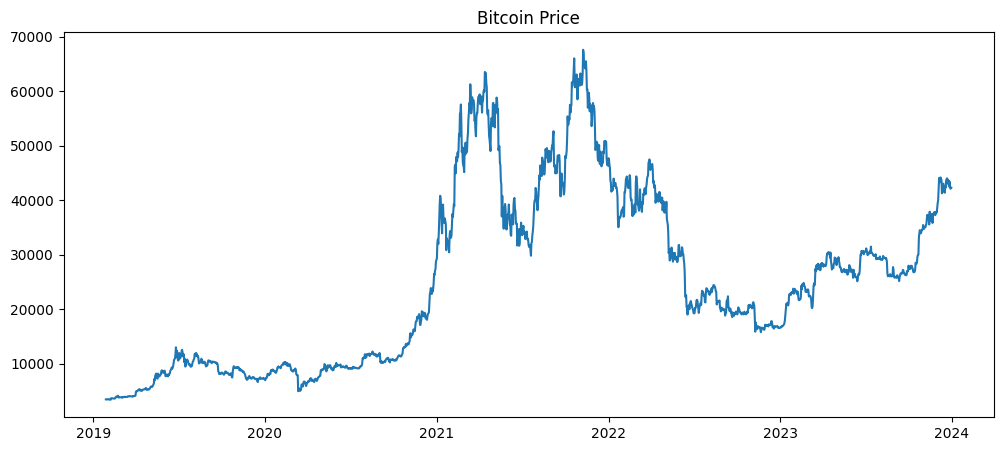

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(data["Close"])
plt.title("Bitcoin Price")
plt.show()

Graph - Returns Series

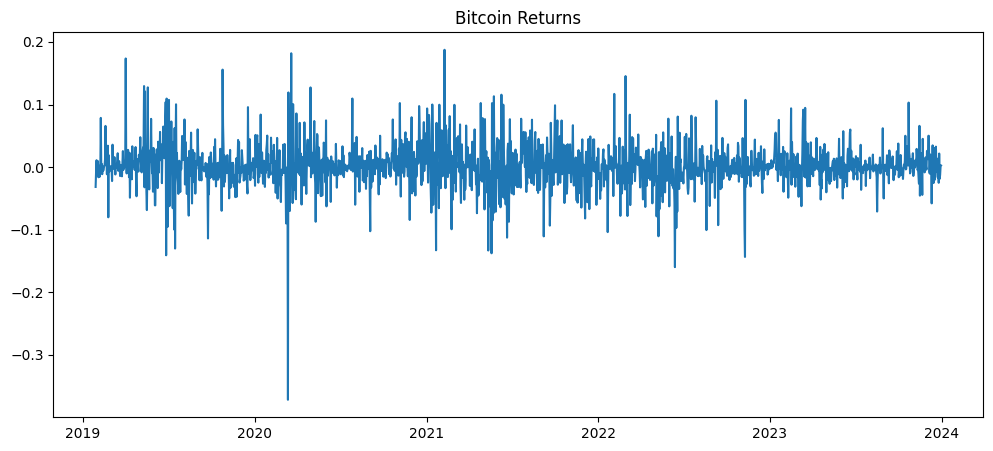

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(data["Returns"])
plt.title("Bitcoin Returns")
plt.show()

Step 1b - Create Features and Labels (with leakage)

In [ ]:
for i in range(1,6):
    data[f"lag_{i}"] = data["Returns"].shift(i)

data["Target"] = data["Returns"].shift(-1)
data = data.dropna()

features = [f"lag_{i}" for i in range(1,6)]

X = data[features].values
y = data["Target"].values

Train/Test Split

In [ ]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

Standardize Data

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Step 1c - Model 1 (MLP)

In [ ]:
mlp = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1)
])

mlp.compile(optimizer="adam", loss="mse")

mlp.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0113
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0033
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0023
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0016
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0013
Epoch 16/20
45/45 ━━━━━━━━━━━━

Step 1c - Model 2 (LSTM)

In [ ]:
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

lstm = Sequential([
    LSTM(50, input_shape=(X_train_lstm.shape[1],1)),
    Dense(1)
])

lstm.compile(optimizer="adam", loss="mse")

lstm.fit(X_train_lstm, y_train, epochs=20)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0022
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0014
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0014
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0015
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0015
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0014
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0014
Epoch 16/20
45/45 ━━━━━━━━━━━━

Step 1c - Model 3 (CNN with GAF)

In [ ]:
from pyts.image import GramianAngularField

gaf = GramianAngularField(image_size=5)

X_gaf = gaf.fit_transform(X)

X_train_gaf = X_gaf[:split].reshape(-1,5,5,1)
X_test_gaf = X_gaf[split:].reshape(-1,5,5,1)

cnn = Sequential([
    Conv2D(32,(3,3),activation="relu",input_shape=(5,5,1)),
    Flatten(),
    Dense(64,activation="relu"),
    Dense(1)
])

cnn.compile(optimizer="adam",loss="mse")

cnn.fit(X_train_gaf,y_train,epochs=20)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0036
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0017
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013
Epoch 16/20
45/45 ━

Step 1d - Backtesting

In [ ]:
def backtest(predictions, y_test):
    signals = np.where(predictions > 0, 1, -1)
    strategy_returns = signals.flatten() * y_test
    cumulative = (1 + strategy_returns).cumprod()
    return cumulative

MLP Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


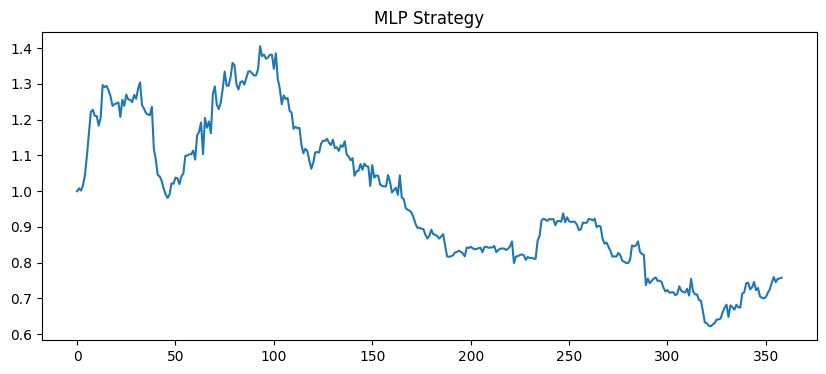

In [ ]:
pred_mlp = mlp.predict(X_test)
cum_mlp = backtest(pred_mlp, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_mlp)
plt.title("MLP Strategy")
plt.show()

LSTM Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step


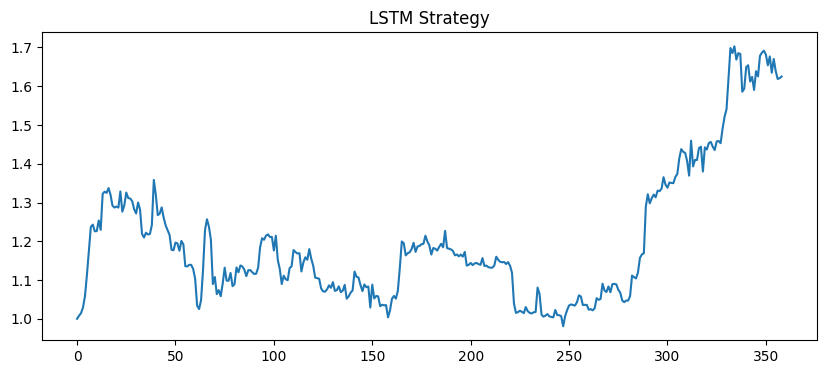

In [ ]:
pred_lstm = lstm.predict(X_test_lstm)
cum_lstm = backtest(pred_lstm, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_lstm)
plt.title("LSTM Strategy")
plt.show()

CNN Strategy

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


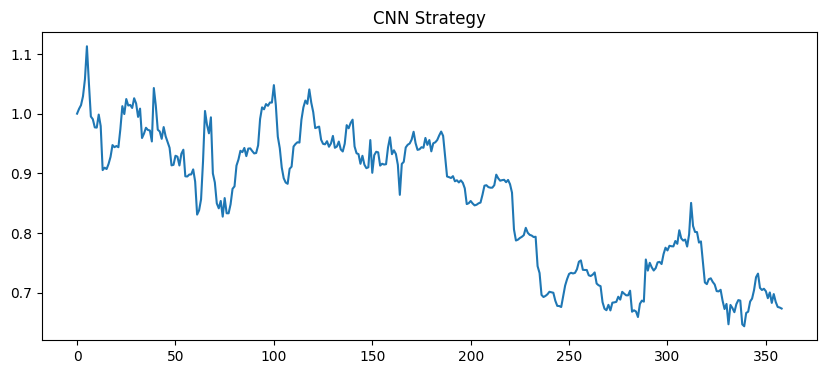

In [ ]:
pred_cnn = cnn.predict(X_test_gaf)
cum_cnn = backtest(pred_cnn, y_test)

plt.figure(figsize=(10,4))
plt.plot(cum_cnn)
plt.title("CNN Strategy")
plt.show()

Step 2a - Walk Forward (500 / 500)

In [ ]:
train_size = 500
test_size = 500

results = []

for start in range(0, len(X) - train_size - test_size, test_size):

    X_train_wf = X[start:start+train_size]
    y_train_wf = y[start:start+train_size]

    X_test_wf = X[start+train_size:start+train_size+test_size]
    y_test_wf = y[start+train_size:start+train_size+test_size]

    scaler = StandardScaler()
    X_train_wf = scaler.fit_transform(X_train_wf)
    X_test_wf = scaler.transform(X_test_wf)

    model = Sequential([
        Dense(32, activation="relu", input_shape=(X_train_wf.shape[1],)),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_wf, y_train_wf, epochs=10, verbose=0)

    pred = model.predict(X_test_wf)
    results.extend(pred.flatten())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Step 2b - Walk Forward (500 / 100)

In [ ]:
train_size = 500
test_size = 100

wf_returns = []

for start in range(0, len(X) - train_size - test_size, test_size):

    X_train_wf = X[start:start+train_size]
    y_train_wf = y[start:start+train_size]

    X_test_wf = X[start+train_size:start+train_size+test_size]
    y_test_wf = y[start+train_size:start+train_size+test_size]

    scaler = StandardScaler()
    X_train_wf = scaler.fit_transform(X_train_wf)
    X_test_wf = scaler.transform(X_test_wf)

    model = Sequential([
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(optimizer="adam", loss="mse")
    model.fit(X_train_wf, y_train_wf, epochs=10, verbose=0)

    pred = model.predict(X_test_wf)
    signals = np.where(pred > 0, 1, -1)
    strategy = signals.flatten() * y_test_wf
    wf_returns.extend(strategy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


Plot Walk Forward Performance

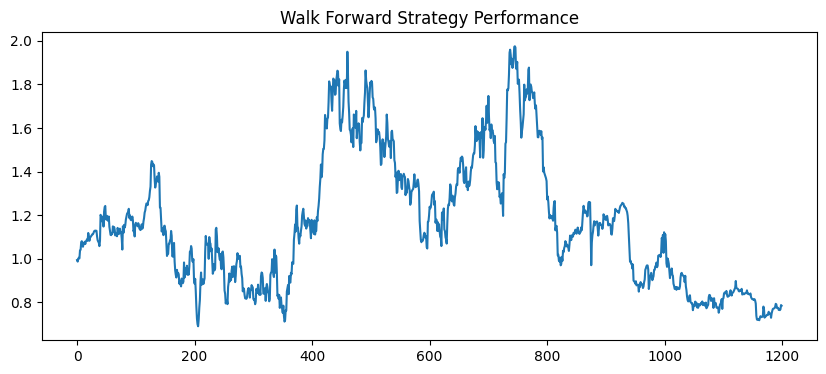

In [ ]:
cum_wf = (1 + np.array(wf_returns)).cumprod()

plt.figure(figsize=(10,4))
plt.plot(cum_wf)
plt.title("Walk Forward Strategy Performance")
plt.show()

Step 3 - Reduce Leakage

Purged Split

In [ ]:
gap = 5

X_train_clean = X[:split-gap]
y_train_clean = y[:split-gap]

X_test_clean = X[split:]
y_test_clean = y[split:]

Retrain Model Without Leakage

In [ ]:
scaler = StandardScaler()
X_train_clean = scaler.fit_transform(X_train_clean)
X_test_clean = scaler.transform(X_test_clean)

model_clean = Sequential([
    Dense(64, activation="relu"),
    Dense(1)
])

model_clean.compile(optimizer="adam", loss="mse")

model_clean.fit(X_train_clean, y_train_clean, epochs=20)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0569
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0087
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0049
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0036
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0032
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0030
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0028
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0027
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0026
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0025
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023
Epoch 13/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0023
Epoch 14/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 15/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 16/20
45/45 ━

Backtest Clean Model

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


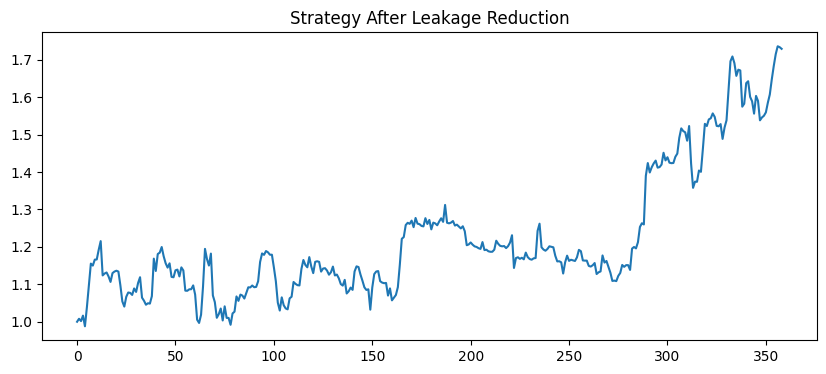

In [ ]:
pred_clean = model_clean.predict(X_test_clean)

cum_clean = backtest(pred_clean, y_test_clean)

plt.figure(figsize=(10,4))
plt.plot(cum_clean)
plt.title("Strategy After Leakage Reduction")
plt.show()